In [4]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
from sklearn.preprocessing  import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,roc_curve
from sklearn.preprocessing import label_binarize

In [5]:
df=pd.read_csv("iris_multi_class.csv")
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [7]:
x=df.drop("species",axis=1)
y=df["species"]

In [9]:
y_encodeed=pd.factorize(y)[0]
y_encodeed

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [11]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [12]:
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)


In [16]:
model=LogisticRegression(max_iter=1000)
model.fit(x_train,y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [17]:
y_pred=model.predict(x_test)

In [14]:
#Generate classsification report
class_report=classification_report(y_test,y_pred)
print("Classification report:")
print(class_report)

Classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [15]:
confusion_mat=confusion_matrix(y_test,y_pred)
print("confusion Matrix:")
print(confusion_mat)

confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


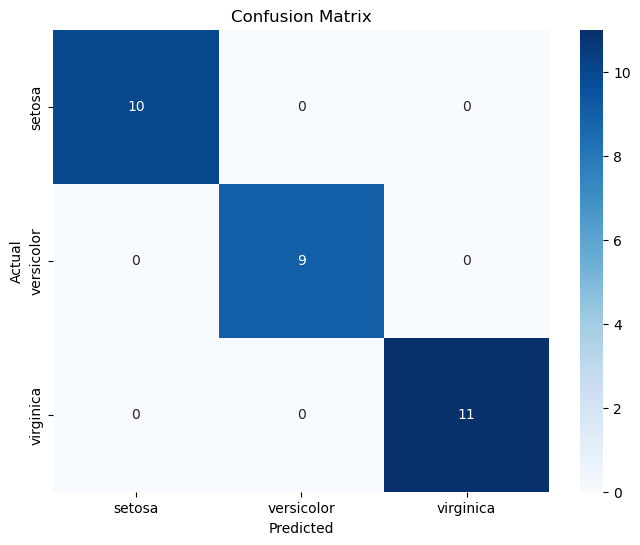

In [20]:
# Plot the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_mat, annot=True, cmap='Blues', fmt='d', xticklabels=df["species"].unique(),
            yticklabels=df["species"].unique())
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [21]:
import numpy as np

# NEW sample
user_input = np.array([[5.1, 3.5, 1.4, 0.2]])

# Predict class and probabilities
pred_class = model.predict(user_input)[0]
pred_prob = model.predict_proba(user_input)[0]

# For multiclass, get class names
class_names = model.classes_  # or use iris.target_names if you have it

# Print results
print("Predicted Species:", pred_class)  # if model.classes_ are strings
print("Probabilities:")
for cls, prob in zip(class_names, pred_prob):
    print(f"{cls.capitalize():12}: {prob:.2f}")


Predicted Species: versicolor
Probabilities:
Setosa      : 0.00
Versicolor  : 0.88
Virginica   : 0.12
